# First Order Ordinary Differential Equations.
General form: $y'+p(x)y=q(x)$


# Imports

In [161]:
import numpy as np
import pandas as pd
import sympy as sp
import scipy 
from sympy.abc import y ,x
import matplotlib.pyplot as plt
from scipy.special import erfi
from sympy import Eq,Derivative,dsolve,Function
from scipy.differentiate import derivative

solve : $y'+xy=x^2y$

In [162]:
y=Function("y")
eq=Eq(Derivative(y(x),x),-x*y(x)+x**2*y(x))
eq

Eq(Derivative(y(x), x), x**2*y(x) - x*y(x))

In [163]:
dsolve(eq)

Eq(y(x), C1*exp(x**2*(2*x - 3)/6))

solve: $y'+xy=0$

In [164]:
eq=Eq(Derivative(y(x),x)+x*y(x),0);
eq

Eq(x*y(x) + Derivative(y(x), x), 0)

In [165]:
dsolve(eq)

Eq(y(x), C1*exp(-x**2/2))

# Solving initial value problem(ivp)

Solve IVP: $y'=6x-3xy+7x^2$

$y(0)=4$


In [166]:
#Getting the solution.
eq=Eq(Derivative(y(x),x),6*x-3*x*y(x)+7*x**2)
eq

Eq(Derivative(y(x), x), 7*x**2 - 3*x*y(x) + 6*x)

In [167]:
dsolve(eq)

Eq(y(x), C1*exp(-3*x**2/2) + 7*x/3 + 2 - 7*sqrt(6)*sqrt(pi)*exp(-3*x**2/2)*erfi(sqrt(6)*x/2)/18)

In [168]:
#solving the initial value problem
sol=dsolve(eq,ics={y(0):4})


In [169]:
#plotting a family of the solution
y_exp=sol.rhs
y_exp

7*x/3 + 2 - 7*sqrt(6)*sqrt(pi)*exp(-3*x**2/2)*erfi(sqrt(6)*x/2)/18 + 2*exp(-3*x**2/2)

In [170]:

f = sp.lambdify(x, y_exp, modules=["numpy", {"erfi": erfi}])

In [171]:
x_values=np.linspace(-4,4,1000);
y_values=f(x_values)

In [172]:
#numerical_derivative using scipy
der=derivative(f,x_values)
y_der=der.df
y_der.shape

(1000,)

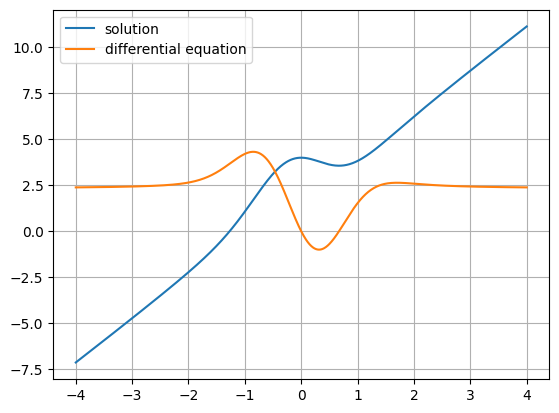

In [173]:
plt.plot(x_values,y_values,label="solution")
plt.plot(x_values,y_der,label="differential equation")
plt.grid()
plt.legend();

In [174]:
#plotting a family of solutions. varying from y(0)=4 to y(0)=10

In [175]:
def get_y(eq):
    x_values = np.linspace(-4, 4, 100)
    initials = [1, 2, 3, 4, 5, 6]

    y_sets = []

    for initial in initials:
        sol = sp.dsolve(eq, ics={y(0): initial})
        y_exp = sol.rhs

        f = sp.lambdify(x, y_exp, modules=["numpy", {"erfi": erfi}])
        y_sets.append(f(x_values))

    return x_values, y_sets

In [176]:
x_values,y_values=get_y(eq)


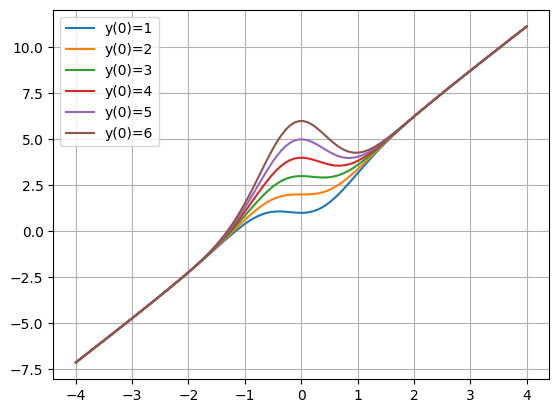

In [177]:
import matplotlib.pyplot as plt

for i, y in enumerate(y_values):
    plt.plot(x_values, y, label=f"y(0)={i+1}")

plt.legend()
plt.grid()
plt.show()